# 📏 Normalization — Why Scale the Data?

When features have different units and magnitudes, machine learning models 
can be misled — not because the data is wrong, but because the scale is unfair.

In this notebook we explore **MinMaxScaler** — what it does, why it matters, 
and where it breaks down — using a Wine Quality dataset with features like 
`alcohol` (8–14%), `pH` (2.7–4.0), and `total sulfur dioxide` (ranging into the hundreds).

**What this notebook covers:**
- How MinMaxScaler transforms data and why fit/transform separation matters
- Visual proof that scaling preserves distribution shape (scatter + KDE plots)
- Why features on wildly different scales distort distance-based comparisons
- How outliers corrupt MinMaxScaler — and what to use instead

> **Core idea:** scaling doesn't change what the data says — 
> it ensures every feature gets an equal hearing.

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 


In [24]:
# ===========================================
# MODULE 1: IMPORTING DATASET
# ===========================================

#Import the data
df = pd.read_csv("../data/WineQT.csv")
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [25]:
df.drop(columns=['Id'], inplace=True)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [26]:
# ===============================
# MODULE 2: SPLITTING DATA
# ===============================

from sklearn.model_selection import train_test_split

X = df.drop('quality', axis=1) # axis = 1 (for column)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Shape of Training set X : {X_train.shape}")
print(f"Shape of Test set X : {X_test.shape}")


Shape of Training set X : (914, 11)
Shape of Test set X : (229, 11)


## Theory: Min-Max Normalization (`MinMaxScaler`)

**What it does**

Min-Max Scaling (Normalization) rescales every feature so that its values lie within a fixed range, usually **[0, 1]**. It does this using the formula:

$$
X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}
$$

- `X_min` and `X_max` are the minimum and maximum values of that feature, **learned from the training data**.
- The transformation is applied independently to each column (feature), not row-wise.
- After scaling, the minimum value of a feature becomes 0, the maximum becomes 1, and everything else is proportionally scaled in between.

**Why normalize at all**

Features like `fixed acidity`, `total sulfur dioxide`, and `alcohol` are on very different scales (e.g., one might range 0–300, another 8–15). 

- Many ML algorithms — especially distance-based ones (KNN, SVM, K-Means) and gradient-based ones (linear/logistic regression, neural networks) — are sensitive to feature scale.
- Without normalization, features with larger numeric ranges dominate the distance calculation or the gradient updates, even if they aren't more important.




**Key properties of MinMaxScaler**

- Preserves the *shape* of the original distribution — it does not make data more "normal" or Gaussian; it only rescales the range.
- Very sensitive to outliers, since a single extreme value directly sets `X_min` or `X_max`, compressing all other (normal) values into a narrow band. (This is why Module 6 shows degraded scaling after outliers are injected.)
- Different from **Standardization** (`StandardScaler`), which centers data using mean and standard deviation ($z = \frac{X - \mu}{\sigma}$) instead of min/max, and does not bound values to a fixed range.

In [27]:
# =========================================
# MODULE 3: Normalization (MinMaxScaler)
# =========================================

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn parameters 
scaler.fit(X_train)

# Transform train and test sets 
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# converting to pandas data frame 
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train.columns)



**`fit` vs `transform` — why they're separate steps**

- `scaler.fit(X_train)` — computes and stores `X_min` and `X_max` **for each column, using only the training data**. No data is transformed yet; the scaler just learns its parameters.
- `scaler.transform(X_train)` / `scaler.transform(X_test)` — applies the formula above using the min/max values learned in the `fit` step.

**Why fit only on `X_train`, not on the full dataset**

If we fit the scaler on the combined train+test data (or on `X_test` at all), information about the test set's range leaks into the training process — this is called **data leakage**. The model would then be evaluated on data it was indirectly informed about, giving an overly optimistic and unrealistic performance estimate.

Instead, the correct workflow is:
1. Split into train/test **first**.
2. `fit()` the scaler on `X_train` only — it learns min/max from training data.
3. `transform()` both `X_train` and `X_test` using *those same* learned parameters.

- This mirrors real-world deployment: at inference time we won't have access to future/unseen data's min or max, so the scaler must rely only on what it learned during training. 

- Because of this, `X_test_scaled` values are **not guaranteed** to fall exactly within [0, 1] — if the test set contains a value outside the training set's observed range, the scaled result can go slightly below 0 or above 1. This is expected and correct behavior.


In [28]:
# Info Of Data
# Before Scaling 
X_train.describe().round(1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0
mean,8.3,0.5,0.3,2.5,0.1,15.7,45.8,1.0,3.3,0.7,10.4
std,1.7,0.2,0.2,1.3,0.0,10.2,31.9,0.0,0.2,0.2,1.1
min,4.6,0.1,0.0,0.9,0.0,1.0,6.0,1.0,2.7,0.3,8.4
25%,7.1,0.4,0.1,1.9,0.1,7.0,21.0,1.0,3.2,0.6,9.5
50%,7.9,0.5,0.2,2.2,0.1,13.0,38.0,1.0,3.3,0.6,10.2
75%,9.0,0.6,0.4,2.6,0.1,21.0,62.0,1.0,3.4,0.7,11.2
max,15.6,1.6,1.0,15.5,0.6,68.0,278.0,1.0,4.0,2.0,14.0


In [29]:
# After Scaling 
X_train_scaled.describe().round(1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0,914.0
mean,0.3,0.3,0.3,0.1,0.1,0.2,0.1,0.5,0.5,0.2,0.4
std,0.2,0.1,0.2,0.1,0.1,0.2,0.1,0.1,0.1,0.1,0.2
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.2,0.2,0.1,0.1,0.1,0.1,0.1,0.4,0.4,0.1,0.2
50%,0.3,0.3,0.2,0.1,0.1,0.2,0.1,0.5,0.4,0.2,0.3
75%,0.4,0.4,0.4,0.1,0.1,0.3,0.2,0.6,0.5,0.2,0.5
max,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


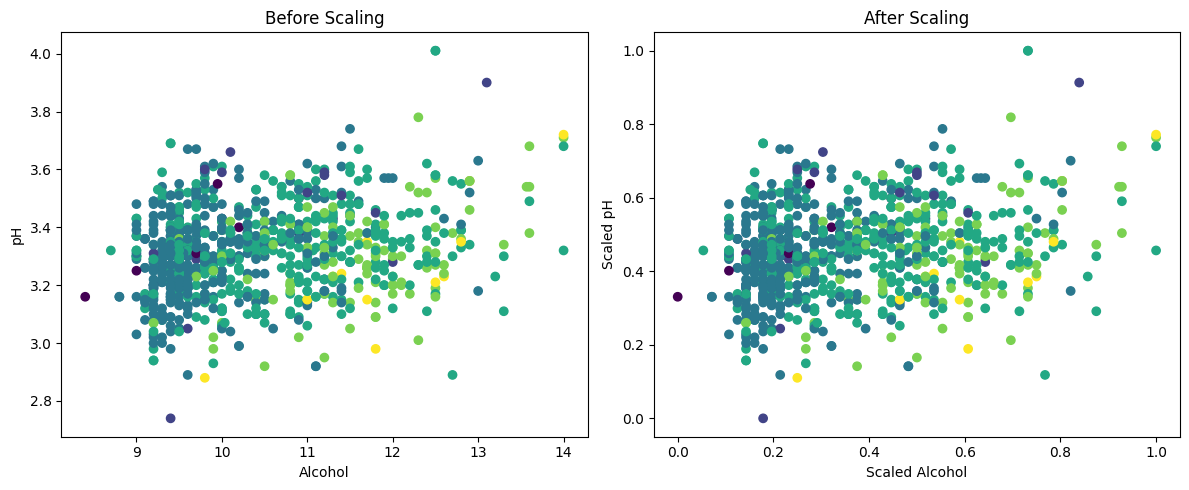

In [31]:
# ==============================
# MODULE 4: EFFECT OF SCALING
# ==============================

# 1. Spread of data

fig, (axis1, axis2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
axis1.scatter(X_train['alcohol'], X_train['pH'], c=y_train)
axis1.set_xlabel("Alcohol")
axis1.set_ylabel("pH")
axis1.set_title("Before Scaling")

# After Scaling
axis2.scatter(X_train_scaled['alcohol'], X_train_scaled['pH'],c=y_train)
axis2.set_xlabel("Scaled Alcohol")
axis2.set_ylabel("Scaled pH")
axis2.set_title("After Scaling")

plt.tight_layout()
plt.show()

## Result Analysis: Effect of Scaling on Data Spread (Alcohol vs pH)

**What the plot shows**

Two scatter plots of the same two features — `alcohol` (x-axis) and `pH` (y-axis) — colored by wine `quality`. The left plot uses the raw, unscaled values; the right plot uses the Min-Max scaled values.

**Observations**

- **Axis ranges changed, shape didn't.** Before scaling, `alcohol` ranges roughly from 8.5 to 14 and `pH` from about 2.7 to 4.0. After scaling, both axes now range from 0 to 1. The *relative positions* of every point to every other point are identical between the two plots — only the numbers on the axes changed.

- **The scatter pattern is preserved.** If you overlay one plot on the other, the cluster shapes, spread, and relationships between points (which points are close together, which are outliers, which colors group where) are exactly the same. Min-Max scaling is a linear transformation, so it stretches or compresses each axis uniformly — it cannot distort, rotate, or reshape the data distribution.

- **Relative distances between features are now comparable.** Before scaling, "1 unit" on the pH axis (range ~1.3) is not remotely comparable to "1 unit" on the alcohol axis (range ~5.5) — a distance-based algorithm would treat alcohol differences as far more significant purely because of its larger numeric range. After scaling, both features occupy the same [0, 1] range, so no feature dominates a distance/gradient calculation just because of its original units.

- **No new information is created.** Scaling doesn't change which quality class (color) a point belongs to, nor does it improve the visual separability between classes — the classes are just as (poorly) mixed after scaling as before. This confirms scaling is purely a preprocessing step for numerical stability, not a way to improve class separation on its own.

**Conclusion**

This confirms the core theoretical property of `MinMaxScaler`: it changes the **scale/range** of the data, not its **shape or structure**. This is exactly why scaling is necessary before feeding data into scale-sensitive algorithms (KNN, SVM, gradient descent–based models) — it puts features on equal footing without altering the relationships the model needs to learn from.

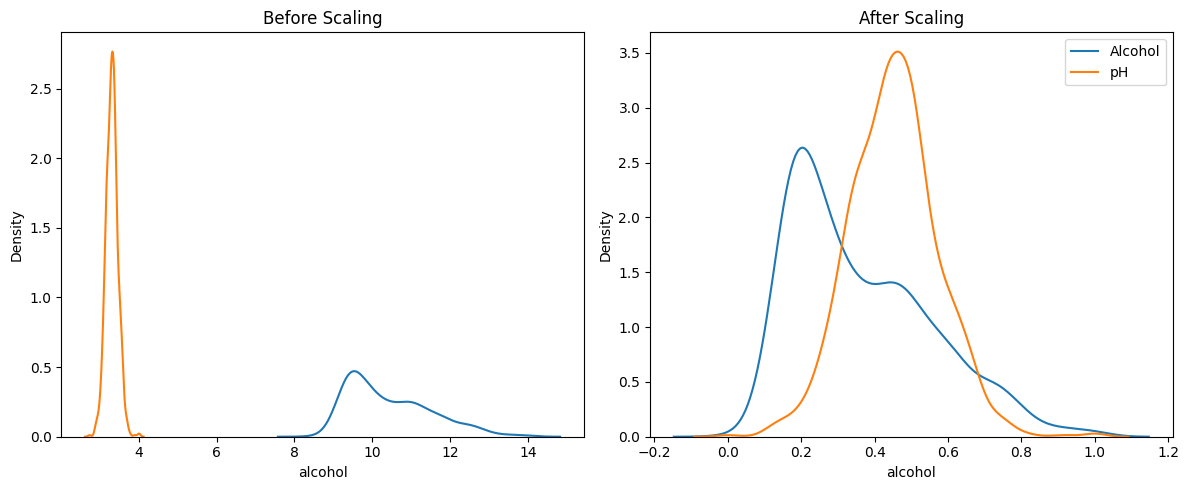

In [32]:
# 2. Kernel Density Estimate (KDE) 

fig, (axis1, axis2) = plt.subplots(ncols=2, figsize=(12,5))
# Before Scaling
sns.kdeplot(X_train['alcohol'], ax=axis1)
sns.kdeplot(X_train['pH'], ax=axis1)
axis1.set_title("Before Scaling")

sns.kdeplot(X_train_scaled['alcohol'], ax=axis2, label='Alcohol')
sns.kdeplot(X_train_scaled['pH'], ax=axis2, label='pH')
axis2.set_title("After Scaling")

plt.tight_layout()
plt.legend()
plt.show()

## Result Analysis: KDE of Alcohol and pH Before vs After Scaling

**What the plot shows**

Kernel Density Estimate (KDE) curves comparing the distribution shape of `alcohol` and `pH` before and after Min-Max scaling.

**Observations**

- **Before scaling**, the two curves sit on completely different parts of the x-axis — `pH` is a tall, narrow peak concentrated around 3–4, while `alcohol` is a wider, flatter peak around 9–14. This isn't because their distributions are fundamentally different in shape; it's because they're on different numeric scales, so plotting them on one shared x-axis makes them look artificially separated.

- **After scaling**, both curves now occupy the same [0, 1] x-axis range, so they become visually comparable on one plot. `pH` still forms a taller, narrower peak, and `alcohol` a slightly wider one — this reflects that `pH` has lower relative variance (more tightly clustered values) than `alcohol`, even after scaling.

- **The shape of each individual curve is unchanged by scaling** — only its position and horizontal spread on the axis changed. Min-Max scaling is a linear transform, so it cannot make a skewed distribution symmetric or a multi-modal one unimodal; it only compresses/stretches the x-axis.


**Conclusion**

This plot reinforces that scaling changes axis range, not distribution shape — but for a rigorous "before vs after" comparison, the same feature and same data split should be used on both sides, as done in the following cell.

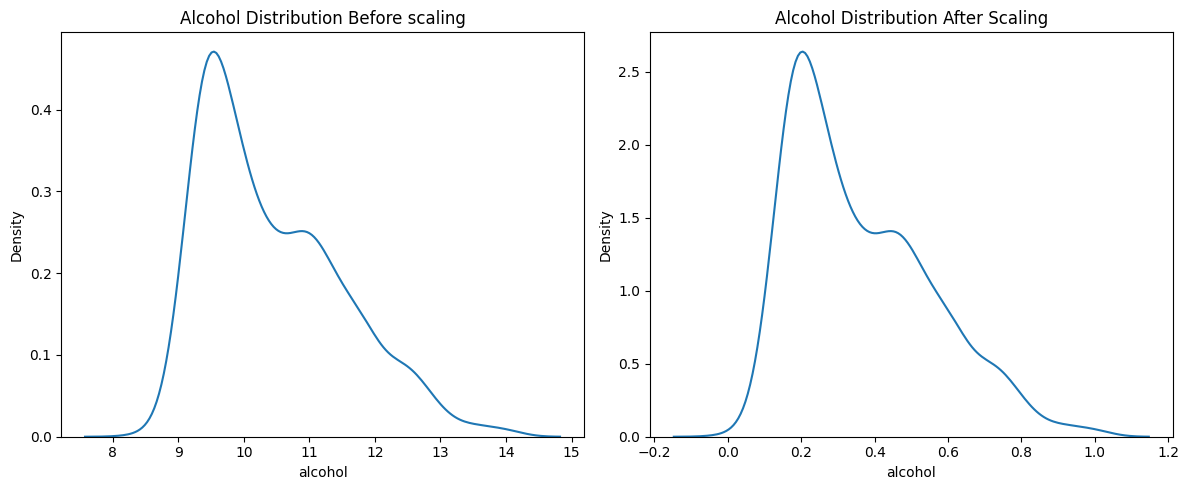

In [18]:
# 3. Kernel Density Estimate (KDE) for Alcohol -- characteristic plot remains the same
fig, (axis1, axis2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling 
sns.kdeplot(X_train['alcohol'], ax=axis1)
axis1.set_title("Alcohol Distribution Before scaling")


# After scaling 
sns.kdeplot(X_train_scaled['alcohol'], ax=axis2)
axis2.set_title('Alcohol Distribution After Scaling')


plt.tight_layout()
plt.show()

In [19]:
# ===============================
# MODULE 6: EFFECT OF OUTLIERS 
# ===============================

# Adding Outliers in the data 
# Adding Outliers in the data 
outliers = pd.DataFrame({
    'fixed acidity': [19.0, 18.5, 20.0],
    'volatile acidity': [2.0, 2.1, 1.8],
    'citric acid': [1.5, 1.6, 1.4],
    'residual sugar': [25.0, 30.0, 20.0],
    'chlorides': [0.9, 1.0, 0.8],
    'free sulfur dioxide': [120, 150, 100],
    'total sulfur dioxide': [400, 450, 350],
    'density': [1.005, 1.010, 1.002],
    'pH': [4.5, 4.6, 4.4],
    'sulphates': [3.0, 3.5, 2.8],
    'alcohol': [18.0, 17.5, 19.0]
})

# Append the data 
df = pd.concat([df, outliers], ignore_index=True)
#df = df.drop(columns=['User ID', 'Gender'])
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0


In [20]:
X = df.drop('quality', axis=1) # axis = 1 (for column)
y = df['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Shape of Training set X : {X_train.shape}")
print(f"Shape of Test set X : {X_test.shape}")

scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn parameters 
scaler.fit(X_train)

# Transform train and test sets 
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# converting to pandas data frame 
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_train.columns)



Shape of Training set X : (916, 11)
Shape of Test set X : (230, 11)


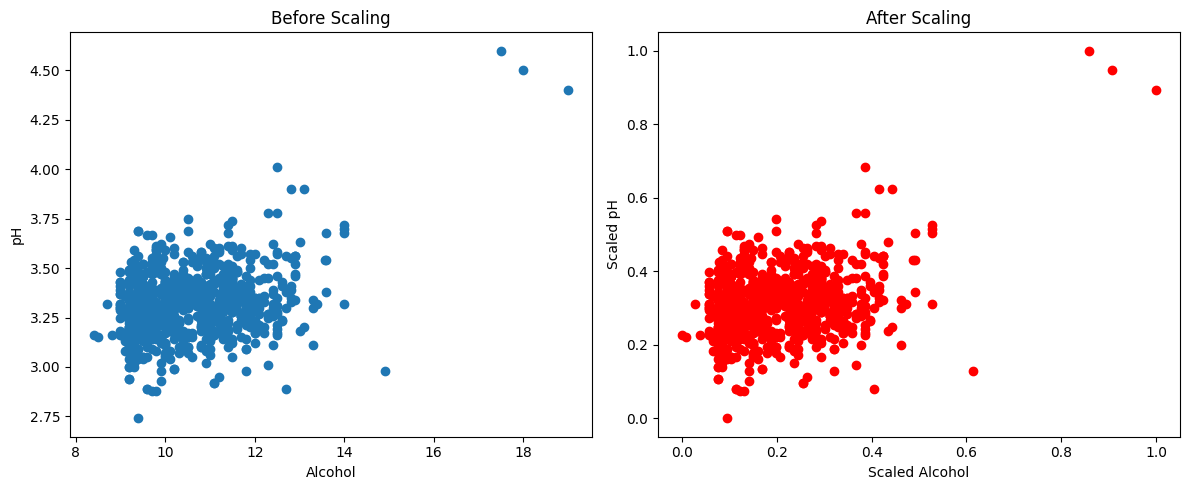

In [22]:
fig, (axis1, axis2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
axis1.scatter(X_train['alcohol'], X_train['pH'])
axis1.set_xlabel("Alcohol")
axis1.set_ylabel("pH")
axis1.set_title("Before Scaling")

# After Scaling
axis2.scatter(X_train_scaled['alcohol'], X_train_scaled['pH'], color = 'red')
axis2.set_xlabel("Scaled Alcohol")
axis2.set_ylabel("Scaled pH")
axis2.set_title("After Scaling")

plt.tight_layout()
plt.show()

## Result Analysis: Effect of Outliers on Min-Max Scaling

**What the plot shows**

Scatter plots of `alcohol` vs `pH` after synthetic outliers (alcohol values of 17.5–19, pH values of 4.4–4.6) were injected into the dataset, split, and scaled again with `MinMaxScaler`.

**Observations**

- **A few outlier points dominate the entire scale.** Before scaling, the bulk of the data (the normal wine samples) sits tightly clustered between alcohol 8–14 and pH 2.75–4.0, with the 3 injected outliers sitting far off to the right (alcohol ~17.5–19, pH ~4.4–4.6).

- **After scaling, the bulk of the data gets crushed into a small corner.** Because `MinMaxScaler` sets 0 and 1 using only the observed `X_min` and `X_max`, the 3 extreme outlier points now define the top of the scale (close to 1.0 on both axes). Every normal data point — which is the vast majority of the dataset — gets compressed into roughly the bottom-left 0–0.4 region of the plot.

- **Loss of resolution among normal points.** In the "before" plot, the normal cluster has visible internal spread (you can distinguish denser vs sparser regions). In the "after" plot, that same cluster is squeezed into a much smaller visual/numeric range, making it harder for a downstream model to distinguish between normal data points — their scaled values are now much closer together than they should meaningfully be.

- **This is the core weakness of Min-Max scaling**: it uses only two data points (the min and the max) to define the entire transformation. A single extreme value — even just one row out of a thousand — can single-handedly shift where every other point lands after scaling. `MinMaxScaler` has no concept of "typical spread"; it only knows the absolute minimum and maximum.

**Why this matters for modeling**

If this scaled data were fed into a distance-based algorithm (KNN, K-Means, SVM), the 3 outlier points would appear to be extremely far from everything else (near 1.0), while all real, meaningful variation among the actual wine samples would be flattened into a tiny sub-region — effectively erasing the differences a model needs to learn from.

**What this calls for**

This is exactly the scenario where **`RobustScaler`** is preferable — it scales using the median and interquartile range (IQR) instead of min/max, so it isn't pulled around by a handful of extreme values. Alternatively, outliers could be detected and removed/capped (e.g., via IQR or z-score thresholding) before applying `MinMaxScaler`. Right now, the notebook shows the *problem* outliers cause but doesn't yet show either fix — that would be a natural next section to add.

**Conclusion**

This confirms theoretically that `MinMaxScaler` is **not robust to outliers** — its output is entirely dependent on the two extreme values in the dataset, which is a key limitation to know when choosing a scaler for real-world (outlier-prone) data.